<a href="https://colab.research.google.com/github/ikabrain/UCS772-CV-NLP-Lab/blob/main/NLP_assign4/NLP_assign4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 4 - Sentiment Analysis
---

In [1]:
import pandas as pd
import nltk

In [2]:
# Download and extract IMDb Large Movie Review Dataset
import os
import tarfile
import urllib.request

url = "http://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
filename = "aclImdb_v1.tar.gz"

if not os.path.exists(filename):
    urllib.request.urlretrieve(url, filename)  # ~80MB, may take a minute

if not os.path.exists("aclImdb"):
    with tarfile.open(filename) as tar:
        tar.extractall(filter='data')

In [3]:
# Loading dataset into a Pandas DataFrame
def load_reviews(split):
    data = []
    for label in ['pos', 'neg']:
        folder = os.path.join('aclImdb', split, label)
        for fname in os.listdir(folder):
            if fname.endswith('.txt'):
                with open(os.path.join(folder, fname), encoding='utf-8') as f:
                    data.append((f.read(), label))
    return pd.DataFrame(data, columns=['review', 'sentiment'])

train_df = load_reviews('train')
test_df = load_reviews('test')

train_df.head()

,review,sentiment
0,Just the kind of movie I love. Some very good ...,pos
1,"I can not quite understand why any of the ""rev...",pos
2,"Alain Chabat is a fine actor, writer and direc...",pos
3,this is a great film!!!<br /><br />I first saw...,pos
4,"Sure, it was cheesy and nonsensical and at tim...",pos


In [4]:
print(f"Training shape: {train_df.shape}")
print(f"Testing shape: {train_df.shape}")

Training shape: (25000, 2)
Testing shape: (25000, 2)


In [5]:
train_df['sentiment'].value_counts()

,count
sentiment,
pos,12500
neg,12500


In [6]:
X_train, y_train = train_df['review'], train_df['sentiment']
X_test, y_test = test_df['review'], test_df['sentiment']

In [7]:
# Removing HTML tags from the reviews
import re

def clean_html(text):
    return re.sub(r"<[^>]+>", " ", text)

X_train = X_train.apply(clean_html)
X_test = X_test.apply(clean_html)

assert not X_train.str.contains("<br", regex=False).any(), "HTML tags still present after cleaning"
assert not X_test.str.contains("<br", regex=False).any(), "HTML tags still present after cleaning"
print("HTML markup removed. Example cleaned review:\n", X_train.iloc[0][:300])

HTML markup removed. Example cleaned review:
 Just the kind of movie I love. Some very good British actors as well as the one and only Sharon Stone. Catherine Tramell (Stone) masterfully manipulates a well educated group of people's lives, playing on their frailties to collect experiences to write a murder mystery book. She plays the female psy


Using current versions of scikit-learn, pandas, nltk/spaCy, and matplotlib/seaborn, solve the below questions.

## Q1: Text Vectorization
---


 - Convert text into numerical features using Bag-of-Words (CountVectorizer), TF-IDF (TfidfVectorizer), and modern vectorization tools.
    - Explain, in your own words, the difference between Bag-of-Words and TF-IDF representations. Which one do you expect to perform better for sentiment analysis, and why?

In [8]:
# Init stopwords and lemmatizer for tokenization
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# keep negation words out of the stopword list, or bigrams like "not good" lose their "not"
negation_words = {"not", "no", "nor", "never", "none", "cannot", "without"}
stop_words_nltk = set(stopwords.words("english")) - negation_words
lemmatizer = WordNetLemmatizer()

def lemma_tokenizer(text):
    words = word_tokenize(text.lower())
    return [lemmatizer.lemmatize(w) for w in words if w.isalpha() and w not in stop_words_nltk]

# sanity check: negation words must survive the stopword filter
assert lemma_tokenizer("This was not good.") == ["not", "good"]

In [9]:
# Bag of Words with bigrams capturing negation
from sklearn.feature_extraction.text import CountVectorizer

count_vec = CountVectorizer(tokenizer=lemma_tokenizer, token_pattern=None, ngram_range=(1, 2), max_features=10000)
X_train_cv = count_vec.fit_transform(X_train)
X_test_cv = count_vec.transform(X_test)

train_dtm = pd.DataFrame(X_train_cv.toarray(), columns=count_vec.get_feature_names_out())
train_dtm.index = X_train.index
train_dtm.head()

,aaron,abandon,abandoned,abc,ability,able,able get,able see,abomination,abortion,...,zane,zero,zizek,zombi,zombie,zombie film,zombie movie,zone,zoom,zorro
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
# TF-IDF with bigrams capturing negation
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vec = TfidfVectorizer(tokenizer=lemma_tokenizer, token_pattern=None, ngram_range=(1, 2), max_features=10000)
X_train_tfidf = tfidf_vec.fit_transform(X_train)
X_test_tfidf = tfidf_vec.transform(X_test)

train_tfidf = pd.DataFrame(X_train_tfidf.toarray(), columns=tfidf_vec.get_feature_names_out())
train_tfidf.index = X_train.index
train_tfidf.head()

,aaron,abandon,abandoned,abc,ability,able,able get,able see,abomination,abortion,...,zane,zero,zizek,zombi,zombie,zombie film,zombie movie,zone,zoom,zorro
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Bag-of-Words just counts how many times each word shows up in a review. Every word gets equal weight, so common words like "movie" or "film" end up with high counts even though they show up in almost every review and don't help separate positive from negative. TF-IDF fixes this by scaling a word's count down if it appears in a lot of documents. A word that shows up a lot in one review but rarely across the whole dataset gets a high score, while a word that's everywhere gets pushed toward zero. So TF-IDF is Bag-of-Words plus a penalty for being too common.

I'd expect TF-IDF to do slightly better for sentiment analysis. Sentiment mostly comes from a handful of strong opinion words in a review, like "great", "terrible", "boring", or "brilliant", and these aren't always the most frequent words in the document. TF-IDF gives more weight to distinctive words like these instead of generic review vocabulary that shows up everywhere, so a model trained on it should pick up the right signal faster, especially Logistic Regression. Naive Bayes already models word probabilities per class, so the gap between BoW and TF-IDF should be smaller there, but TF-IDF should still help by muting uninformative high frequency words.

## Q2: Word Cloud
---

 - Generate a word cloud for positive reviews and negative reviews. Comment on the most frequent words observed in each class.

In [11]:
# Init fresh lemmatized tokenization for word cloud, with negation words in stopword list
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

stop_words_cloud = set(stopwords.words("english"))
cloud_lemmatizer = WordNetLemmatizer()

def cloud_tokenizer(text):
    words = word_tokenize(text.lower())
    return [cloud_lemmatizer.lemmatize(w) for w in words if w.isalpha() and w not in stop_words_cloud]

In [12]:
# Counting frequencies of lemmatized words
from collections import Counter

pos_words = Counter()
for review in X_train[y_train == "pos"]:
    pos_words.update(cloud_tokenizer(review))

neg_words = Counter()
for review in X_train[y_train == "neg"]:
    neg_words.update(cloud_tokenizer(review))

print(f"Unique lemmatized words: {len(pos_words)} positive, {len(neg_words)} negative")

Unique lemmatized words: 47731 positive, 46345 negative


In [13]:
# Score each word by how disproportionately it favors this class over the other, weighted by its own frequency so rare words can't get an inflated score from noise
import math

def distinctiveness_scores(freq_this, freq_other, min_count=5, smoothing=1):
    scores = {}
    for word, count in freq_this.items():
        if count < min_count:
            continue
        other_count = freq_other.get(word, 0)
        skew = math.log((count + smoothing) / (other_count + smoothing))
        score = count * skew
        if score > 0:
            scores[word] = score
    return scores

pos_scores = distinctiveness_scores(pos_words, neg_words)
neg_scores = distinctiveness_scores(neg_words, pos_words)

assert pos_scores and neg_scores, "expected at least one distinctive word per class"
assert all(s > 0 for s in pos_scores.values()) and all(s > 0 for s in neg_scores.values())

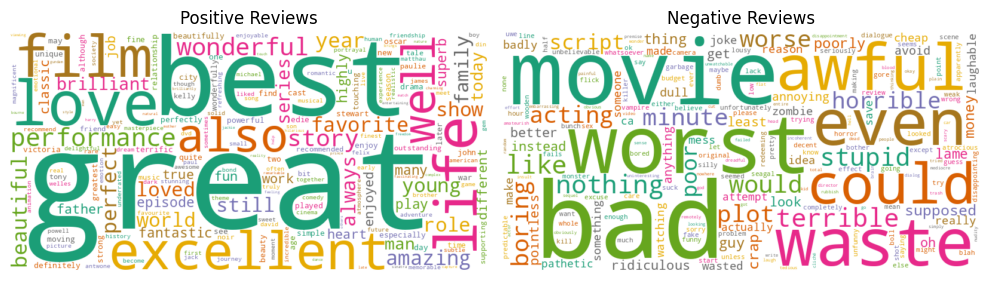

In [14]:
# Making word cloud for positive and negative reviews, sized by class-distinctiveness score
from wordcloud import WordCloud
import matplotlib.pyplot as plt

pos_wc = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="Dark2",
    random_state=42
).generate_from_frequencies(pos_scores)
neg_wc = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="Dark2",
    random_state=42
).generate_from_frequencies(neg_scores)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
for ax, wc, title in zip([ax1, ax2], [pos_wc, neg_wc], ["Positive Reviews", "Negative Reviews"]):
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(title)

plt.tight_layout()
plt.show()

 Once I switched from raw frequency to the distinctiveness score, the two clouds actually look different from each other.

 The positive cloud is full of direct praise: best, great, love, wonderful, brilliant, excellent, amazing, favorite. The negative cloud is full of direct criticism: bad, worst, awful, horrible, terrible, waste, boring, stupid, pathetic.

 A couple of generic words like movie and film still sneak into both sides since every review mentions them, but they're much smaller here than in my first attempt, where raw frequency let them dominate both clouds equally and made positive and negative look almost the same. This version actually shows what's different about each class instead of just what's common to all movie reviews!

## Q3: Sentiment Classification
---

 - Train and evaluate a Naive Bayes classifier and a Logistic Regression classifier for sentiment classification.

In [15]:
# Multinomial Naive-Bayes trained on Bag-of-Words
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import MultinomialNB
import time

nb_cv = MultinomialNB()

start = time.perf_counter()
nb_cv.fit(X_train_cv, y_train)
nb_cv_time = time.perf_counter() - start

print(f"Naive Bayes + BoW training time: {nb_cv_time:.4f} seconds")
print(f"Naive Bayes + BoW accuracy: {accuracy_score(y_test, nb_cv.predict(X_test_cv)):.4f}")

Naive Bayes + BoW training time: 0.0853 seconds
Naive Bayes + BoW accuracy: 0.8488


In [16]:
# Multinomial Naive-Bayes trained on TF-IDF
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import MultinomialNB
import time

nb_tfidf = MultinomialNB()

start = time.perf_counter()
nb_tfidf.fit(X_train_tfidf, y_train)
nb_tfidf_time = time.perf_counter() - start

print(f"Naive Bayes + TF-IDF training time: {nb_tfidf_time:.4f} seconds")
print(f"Naive Bayes + TF-IDF accuracy: {accuracy_score(y_test, nb_tfidf.predict(X_test_tfidf)):.4f}")

Naive Bayes + TF-IDF training time: 0.0562 seconds
Naive Bayes + TF-IDF accuracy: 0.8550


In [17]:
# Logistic Regression trained on TF-IDF
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import time

lr_tfidf = LogisticRegression(max_iter=1000, random_state=42)

start = time.perf_counter()
lr_tfidf.fit(X_train_tfidf, y_train)
lr_tfidf_time = time.perf_counter() - start

print(f"Logistic Regression + TF-IDF training time: {lr_tfidf_time:.4f} seconds")
print(f"Logistic Regression + TF-IDF accuracy: {accuracy_score(y_test, lr_tfidf.predict(X_test_tfidf)):.4f}")

Logistic Regression + TF-IDF training time: 0.3759 seconds
Logistic Regression + TF-IDF accuracy: 0.8867


## Q4: Evaluation Metrics
---

 - Compare the two models using standard evaluation metrics. Build a comparison table summarizing Accuracy, Precision, Recall, F1-score, and training time for:
    - Naive Bayes + Bag-of-Words
    - Naive Bayes + TF-IDF
    - Logistic Regression + TF-IDF

In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score

models = [
    ("Naive Bayes + Bag-of-Words", nb_cv, X_test_cv, nb_cv_time),
    ("Naive Bayes + TF-IDF", nb_tfidf, X_test_tfidf, nb_tfidf_time),
    ("Logistic Regression + TF-IDF", lr_tfidf, X_test_tfidf, lr_tfidf_time),
]

results = []
for name, model, X_test_feat, train_time in models:
    y_pred = model.predict(X_test_feat)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, pos_label="pos"),
        "Recall": recall_score(y_test, y_pred, pos_label="pos"),
        "F1-score": f1_score(y_test, y_pred, pos_label="pos"),
        "Training Time (s)": train_time,
    })

assert len(results) == 3

In [19]:
# Comprehensive comparison table
comparison_table = pd.DataFrame(results).set_index("Model").round(4)
comparison_table

,Accuracy,Precision,Recall,F1-score,Training Time (s)
Model,,,,,
Naive Bayes + Bag-of-Words,0.8488,0.8616,0.8312,0.8461,0.0853
Naive Bayes + TF-IDF,0.8550,0.8617,0.8458,0.8537,0.0562
Logistic Regression + TF-IDF,0.8867,0.8849,0.8890,0.8869,0.3759


## Review
---

Based on your results, answer the following:
<ol type="a">
    <li>Which model performed better overall?</li>
    <li>Which model is more interpretable, and why?</li>
    <li>Which model would you deploy in a production system? Justify your answer.</li>
</ol>

**(a)** **Logistic Regression + TF-IDF** won clearly across every metric, *0.8867 accuracy* and *0.8869 F1*, compared to 0.8550 for Naive Bayes + TF-IDF and 0.8488 for Naive Bayes + BoW. This matches what I predicted in Q1: TF-IDF gave it cleaner signal to work with, and unlike Naive Bayes it can actually *learn how much weight to give each word instead of assuming they're all independent*. Switching Naive Bayes from BoW to TF-IDF only bumped accuracy by about half a point, but switching to Logistic Regression added another 3 points on top of that.

**(b)** **Naive Bayes** is more interpretable. Each word just gets a probability of showing up in positive versus negative reviews, so I can *point at a word and say "this made the review look more positive" without any extra math*. Logistic Regression works in a similar way through its coefficients, direction and strength of a word's pull toward one class, but with 10000 features including bigrams, those coefficients pile up fast and the model is combining a lot of them together for every single prediction, so it's harder to explain a single decision at a glance.

**(c)** I'd deploy **Logistic Regression + TF-IDF**. It wins on every metric in the table, and even though it trains slower than Naive Bayes (0.38s versus 0.06 to 0.09s), that's still fast in absolute terms and training only happens once, not on every prediction. In production what actually matters is how good and reliable the predictions are, and Logistic Regression wins there by a solid margin. Naive Bayes would only make more sense if I needed something that retrains constantly with very little compute to spare.